**Import libraries**

In [9]:
# Install the datasets library
!pip install datasets

In [10]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import pipeline
from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# Loading datasets
train_df = pd.read_csv('/content/drive/MyDrive/Colab-Notebooks/LHL-LLM/data/train_df.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Colab-Notebooks/LHL-LLM/data/test_df.csv')

In [13]:
# Drop unnecessary columns
test_df = test_df.drop(['text_length'], axis = 1)
train_df = train_df.drop(['text_length'], axis = 1)

In [14]:
# Select the first 1000 rows for testing due to computional time
df_subset = test_df.head(1000)

**Load Model**

In [15]:
# Load the sentiment classification pipeline
pipe = pipeline("text-classification", model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [16]:
# Make predictions on the subset of data
predictions = pipe(df_subset['text'].tolist(), truncation=True)

In [17]:
# Because predictions is a list of dictionaries returned from the pipeline I'll change it into pd DataFrame
predicted_labels = [pred['label'] for pred in predictions]
true_labels = df_subset['label'].tolist()

# Create a DataFrame to compare true and predicted labels
results_df = pd.DataFrame({
    'true_label': true_labels,
    'predicted_label': predicted_labels
})

# Display the first few rows
print(results_df.head())

   true_label predicted_label
0           0        NEGATIVE
1           0        POSITIVE
2           0        NEGATIVE
3           0        NEGATIVE
4           0        POSITIVE


In [18]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder
label_encoder = LabelEncoder()

# Fit the encoder to the unique labels
label_encoder.fit(results_df['predicted_label'])

# Transform the predicted labels to integers
results_df['pred_label_int'] = label_encoder.transform(results_df['predicted_label'])

# View the updated DataFrame
print(results_df.head())

   true_label predicted_label  pred_label_int
0           0        NEGATIVE               0
1           0        POSITIVE               1
2           0        NEGATIVE               0
3           0        NEGATIVE               0
4           0        POSITIVE               1


Accuracy: 0.94
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1000
           1       0.00      0.00      0.00         0

    accuracy                           0.94      1000
   macro avg       0.50      0.47      0.49      1000
weighted avg       1.00      0.94      0.97      1000



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


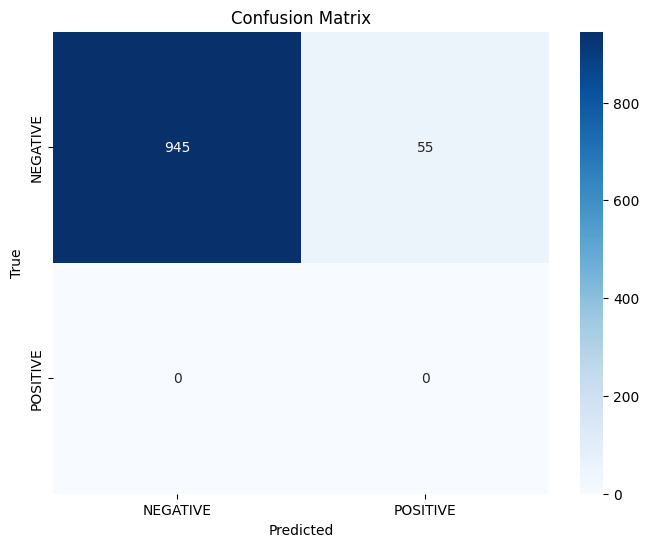

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

y_true = results_df['true_label'].tolist()  # True labels
y_pred = results_df['pred_label_int'].tolist()  # Predicted labels as integers

# Calculate accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Generate classification report
report = classification_report(y_true, y_pred)
print("Classification Report:")
print(report)

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

**Evaluate the model**

**Results analysis**

**Accuracy: 0.94** - this indicates that 94% of the predictions made by the model were correct. However, while this might sound good, it is also misleading as we can see taht there is class imbalance.

**Class 0 ('Negative'):**

- **Precision: 1.00**: The model perfectly predicted all labels for class 0 without any false positives.

- **Recall: 0.94**: The model identified 94% of the actual class 0 cases correctly.

- **F1 Score: 0.97**: A good balance between precision and recall for class 0.

**Class 1 ('Positive')**:

- **Precision: 0.00**: The model failed to predict any labels of class 1. There are no true positives for this class.

- **Recall: 0.00**: The model did not identify any actual labels of class 1, leading to a complete lack of detection.

- **F1 Score: 0.00**: Indicates that the model's performance for class 1 is poor, as it didn’t predict any correct cases.

**Issues Identified**

**Class Imbalance:** the model seems to be heavily biased towards predicting class 0, leading to a failure to predict any instances of class 1. This suggests that class 1 may be underrepresented in the training data or that the model is not generalizing well to identify instances of class 1.

**Model Limitations:** The complete absence of predictions for class 1 indicates that the model may not have learned the features or patterns associated with this class, likely due to its absence in the training dataset or lack of distinct features.